In [ ]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Display settings
sns.set_style("whitegrid")

In [ ]:
# UCI Breast Cancer dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer/breast-cancer.data"

# Column names from dataset documentation
columns = [
    "Class",
    "age",
    "menopause",
    "tumor_size",
    "inv_nodes",
    "node_caps",
    "deg_malig",
    "breast",
    "breast_quad",
    "irradiat"
]

# Load dataset
df = pd.read_csv(url, names=columns)

# Preview data
df.head()

,Class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [ ]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nClass Distribution:")
print(df["Class"].value_counts())

Dataset Shape: (286, 10)

Data Types:
Class          object
age            object
menopause      object
tumor_size     object
inv_nodes      object
node_caps      object
deg_malig       int64
breast         object
breast_quad    object
irradiat       object
dtype: object

Class Distribution:
Class
no-recurrence-events    201
recurrence-events        85
Name: count, dtype: int64


In [ ]:
# Replace ? with NaN
df.replace("?", np.nan, inplace=True)

# Check missing values
df.isnull().sum()

,0
Class,0
age,0
menopause,0
tumor_size,0
inv_nodes,0
node_caps,8
deg_malig,0
breast,0
breast_quad,1
irradiat,0


In [ ]:
# Drop rows with missing values
df = df.dropna()

print("New Shape:", df.shape)

New Shape: (277, 10)


In [ ]:
encoder = LabelEncoder()

for column in df.columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,Class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
0,0,1,2,5,0,0,2,0,1,0
1,0,2,2,3,0,0,1,1,4,0
2,0,2,2,3,0,0,1,0,1,0
3,0,4,0,2,0,0,1,1,2,0
4,0,2,2,0,0,0,1,1,3,0


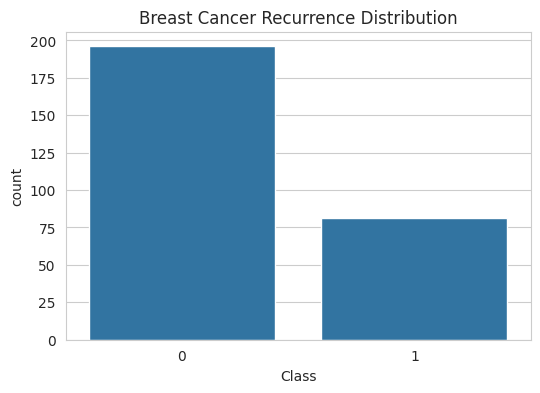

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Breast Cancer Recurrence Distribution")
plt.show()

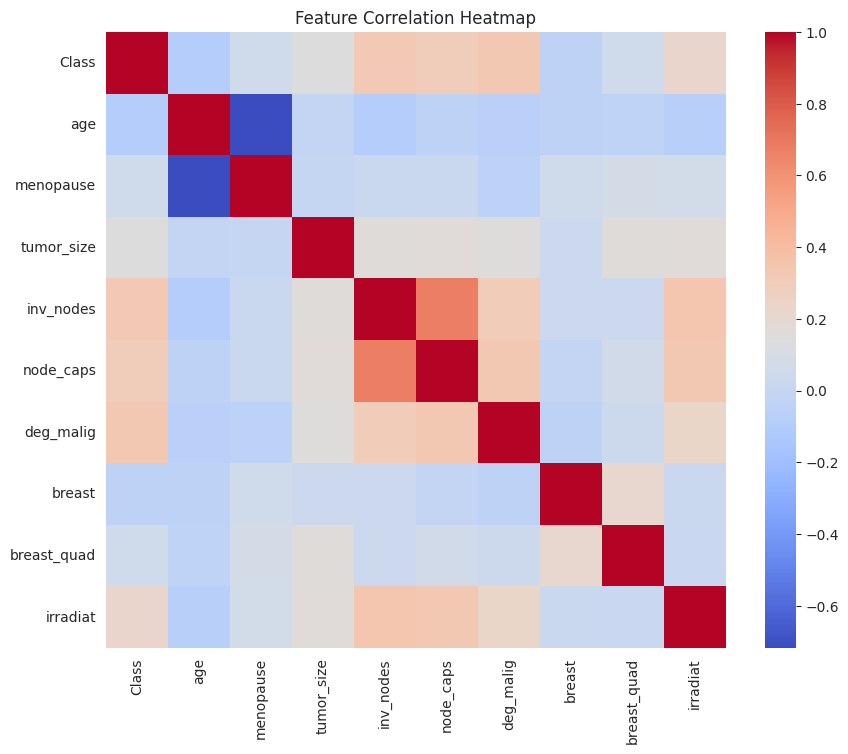

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (221, 9)
Testing Shape: (56, 9)


In [ ]:
print("Dataset Info")
df.info()

print("\nStatistical Summary")
df.describe()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
Index: 277 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Class        277 non-null    int64
 1   age          277 non-null    int64
 2   menopause    277 non-null    int64
 3   tumor_size   277 non-null    int64
 4   inv_nodes    277 non-null    int64
 5   node_caps    277 non-null    int64
 6   deg_malig    277 non-null    int64
 7   breast       277 non-null    int64
 8   breast_quad  277 non-null    int64
 9   irradiat     277 non-null    int64
dtypes: int64(10)
memory usage: 23.8 KB

Statistical Summary


,Class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,breast_quad,irradiat
count,277.000000,277.000000,277.000000,277.000000,277.000000,277.000000,277.000000,277.000000,277.000000,277.000000
mean,0.292419,2.642599,1.093863,4.068592,1.014440,0.202166,1.057762,0.476534,1.787004,0.223827
std,0.455697,1.010125,0.988264,2.178366,1.876574,0.402342,0.729989,0.500353,1.097483,0.417562
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,3.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,0.000000,3.000000,2.000000,4.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
75%,1.000000,3.000000,2.000000,5.000000,0.000000,0.000000,2.000000,1.000000,2.000000,0.000000
max,1.000000,5.000000,2.000000,10.000000,6.000000,1.000000,2.000000,1.000000,4.000000,1.000000


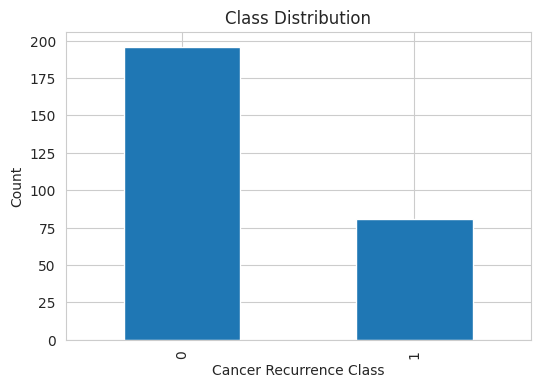

Class
0    0.707581
1    0.292419
Name: count, dtype: float64


In [ ]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Cancer Recurrence Class")
plt.ylabel("Count")
plt.show()

print(class_counts / len(df))

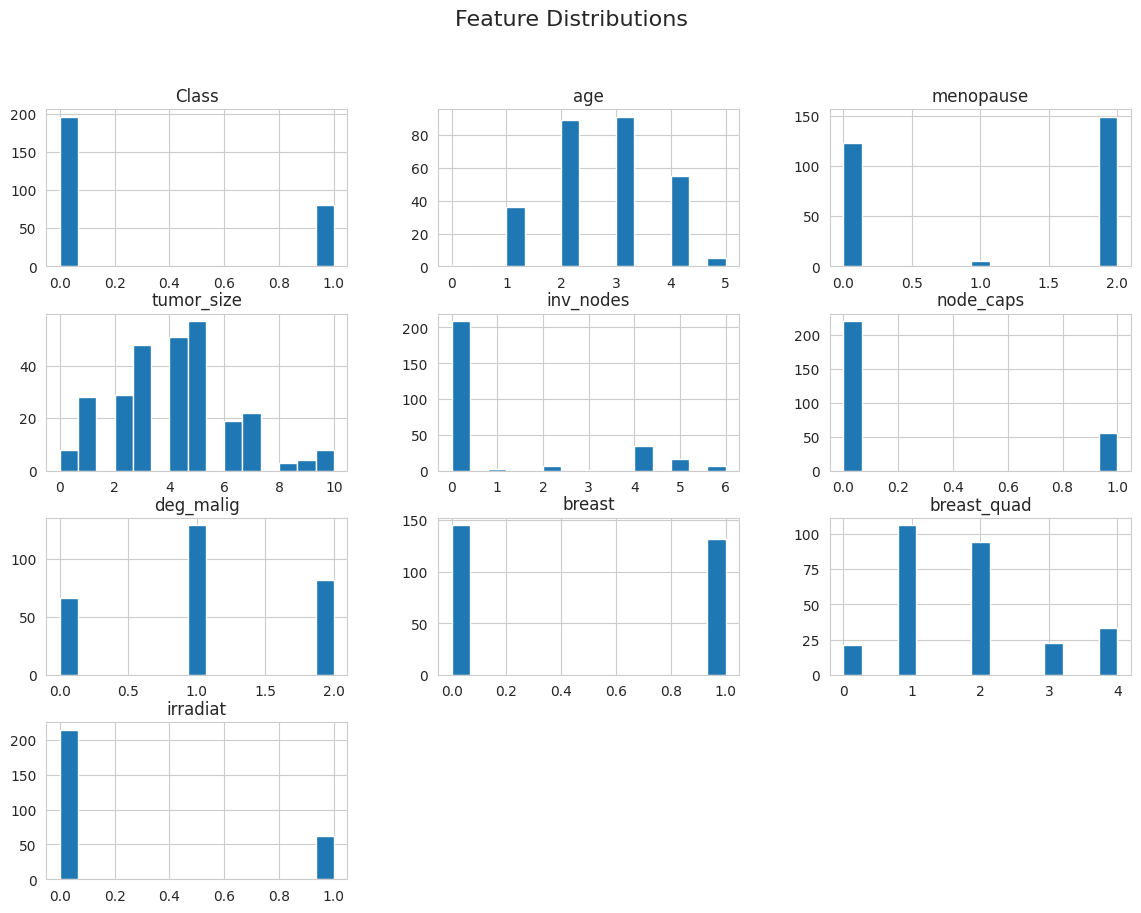

In [ ]:
df.hist(figsize=(14,10), bins=15)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

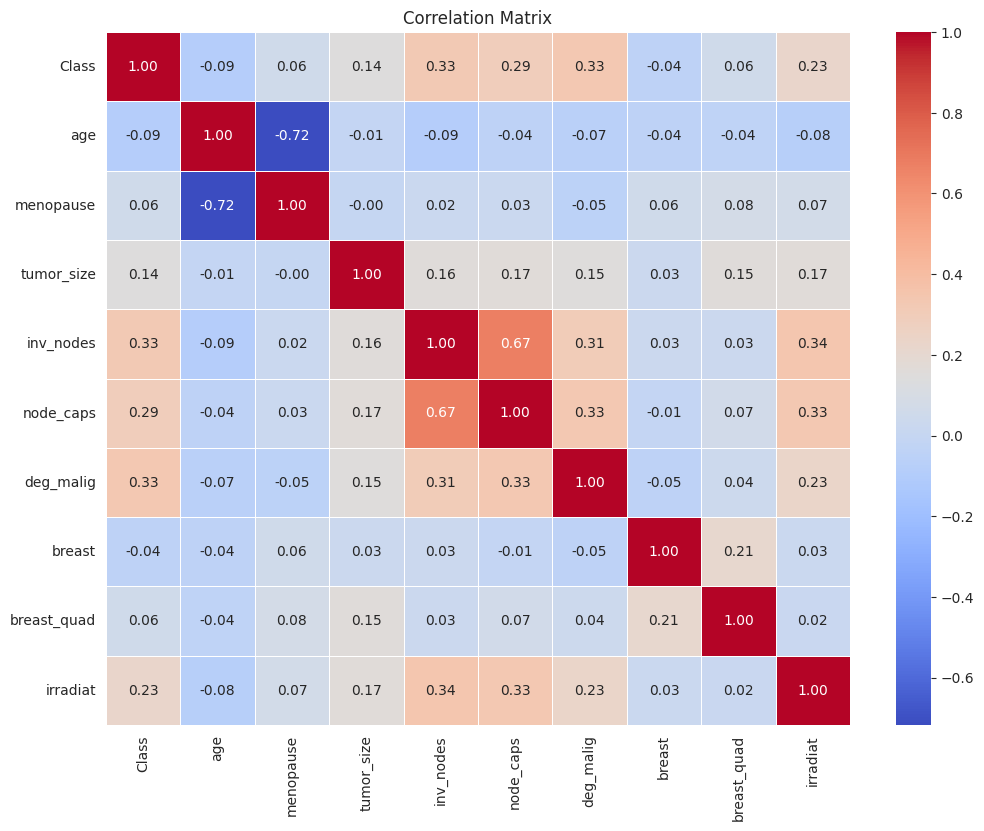

In [ ]:
plt.figure(figsize=(12,9))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

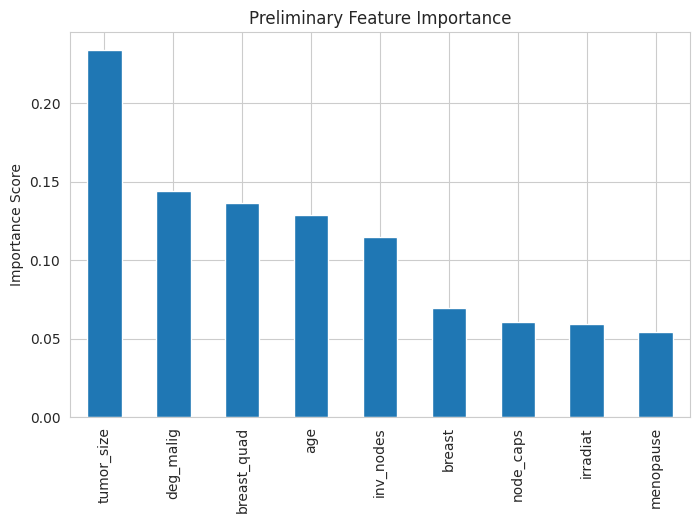

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.title("Preliminary Feature Importance")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_acc = accuracy_score(y_test, y_pred_log)
log_prec = precision_score(y_test, y_pred_log)
log_rec = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression Results")
print("Accuracy:", log_acc)
print("Precision:", log_prec)
print("Recall:", log_rec)
print("F1 Score:", log_f1)

Logistic Regression Results
Accuracy: 0.7678571428571429
Precision: 0.7142857142857143
Recall: 0.3125
F1 Score: 0.43478260869565216


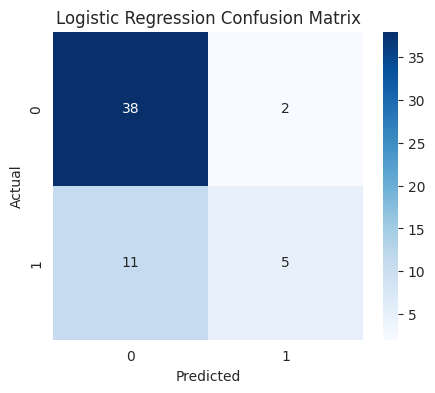

In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("Accuracy:", dt_acc)
print("Precision:", dt_prec)
print("Recall:", dt_rec)
print("F1 Score:", dt_f1)

Decision Tree Results
Accuracy: 0.6607142857142857
Precision: 0.42105263157894735
Recall: 0.5
F1 Score: 0.45714285714285713


In [ ]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy:", rf_acc)
print("Precision:", rf_prec)
print("Recall:", rf_rec)
print("F1 Score:", rf_f1)

Random Forest Results
Accuracy: 0.7857142857142857
Precision: 0.6666666666666666
Recall: 0.5
F1 Score: 0.5714285714285714


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [log_acc, dt_acc, rf_acc],
    "Precision": [log_prec, dt_prec, rf_prec],
    "Recall": [log_rec, dt_rec, rf_rec],
    "F1 Score": [log_f1, dt_f1, rf_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.767857,0.714286,0.3125,0.434783
1,Decision Tree,0.660714,0.421053,0.5000,0.457143
2,Random Forest,0.785714,0.666667,0.5000,0.571429


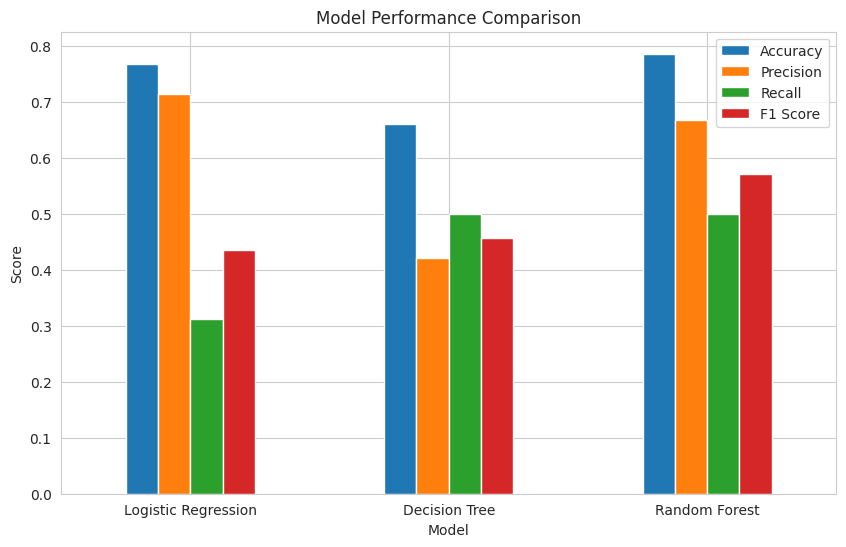

In [ ]:
results.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

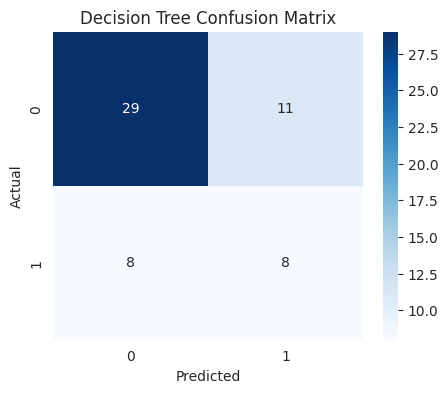

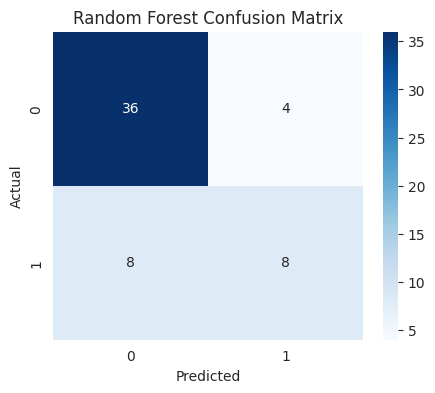

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression Hyperparameter Tuning
param_grid_log = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500, 1000]
}

grid_search_log = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_log,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_log.fit(X_train, y_train)

best_log_model = grid_search_log.best_estimator_

print("Best parameters for Logistic Regression:", grid_search_log.best_params_)

y_pred_log_tuned = best_log_model.predict(X_test)

log_acc_tuned = accuracy_score(y_test, y_pred_log_tuned)
log_prec_tuned = precision_score(y_test, y_pred_log_tuned)
log_rec_tuned = recall_score(y_test, y_pred_log_tuned)
log_f1_tuned = f1_score(y_test, y_pred_log_tuned)

print("\nLogistic Regression Tuned Results")
print("Accuracy:", log_acc_tuned)
print("Precision:", log_prec_tuned)
print("Recall:", log_rec_tuned)
print("F1 Score:", log_f1_tuned)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters for Logistic Regression: {'C': 100, 'max_iter': 100, 'solver': 'liblinear'}

Logistic Regression Tuned Results
Accuracy: 0.7678571428571429
Precision: 0.7142857142857143
Recall: 0.3125
F1 Score: 0.43478260869565216


In [ ]:
# Decision Tree Hyperparameter Tuning
param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

best_dt_model = grid_search_dt.best_estimator_

print("Best parameters for Decision Tree:", grid_search_dt.best_params_)

y_pred_dt_tuned = best_dt_model.predict(X_test)

dt_acc_tuned = accuracy_score(y_test, y_pred_dt_tuned)
dt_prec_tuned = precision_score(y_test, y_pred_dt_tuned)
dt_rec_tuned = recall_score(y_test, y_pred_dt_tuned)
dt_f1_tuned = f1_score(y_test, y_pred_dt_tuned)

print("\nDecision Tree Tuned Results")
print("Accuracy:", dt_acc_tuned)
print("Precision:", dt_prec_tuned)
print("Recall:", dt_rec_tuned)
print("F1 Score:", dt_f1_tuned)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Decision Tree: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}

Decision Tree Tuned Results
Accuracy: 0.6607142857142857
Precision: 0.38461538461538464
Recall: 0.3125
F1 Score: 0.3448275862068966


In [ ]:
# Random Forest Hyperparameter Tuning
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_

print("Best parameters for Random Forest:", grid_search_rf.best_params_)

y_pred_rf_tuned = best_rf_model.predict(X_test)

rf_acc_tuned = accuracy_score(y_test, y_pred_rf_tuned)
rf_prec_tuned = precision_score(y_test, y_pred_rf_tuned)
rf_rec_tuned = recall_score(y_test, y_pred_rf_tuned)
rf_f1_tuned = f1_score(y_test, y_pred_rf_tuned)

print("\nRandom Forest Tuned Results")
print("Accuracy:", rf_acc_tuned)
print("Precision:", rf_prec_tuned)
print("Recall:", rf_rec_tuned)
print("F1 Score:", rf_f1_tuned)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest Tuned Results
Accuracy: 0.7857142857142857
Precision: 0.6666666666666666
Recall: 0.5
F1 Score: 0.5714285714285714


Model Performance Comparison (Original vs. Tuned)
                                Accuracy  Precision  Recall  F1 Score
Model                                                                
Logistic Regression (Original)  0.767857   0.714286  0.3125  0.434783
Logistic Regression (Tuned)     0.767857   0.714286  0.3125  0.434783
Decision Tree (Original)        0.660714   0.421053  0.5000  0.457143
Decision Tree (Tuned)           0.660714   0.384615  0.3125  0.344828
Random Forest (Original)        0.785714   0.666667  0.5000  0.571429
Random Forest (Tuned)           0.785714   0.666667  0.5000  0.571429


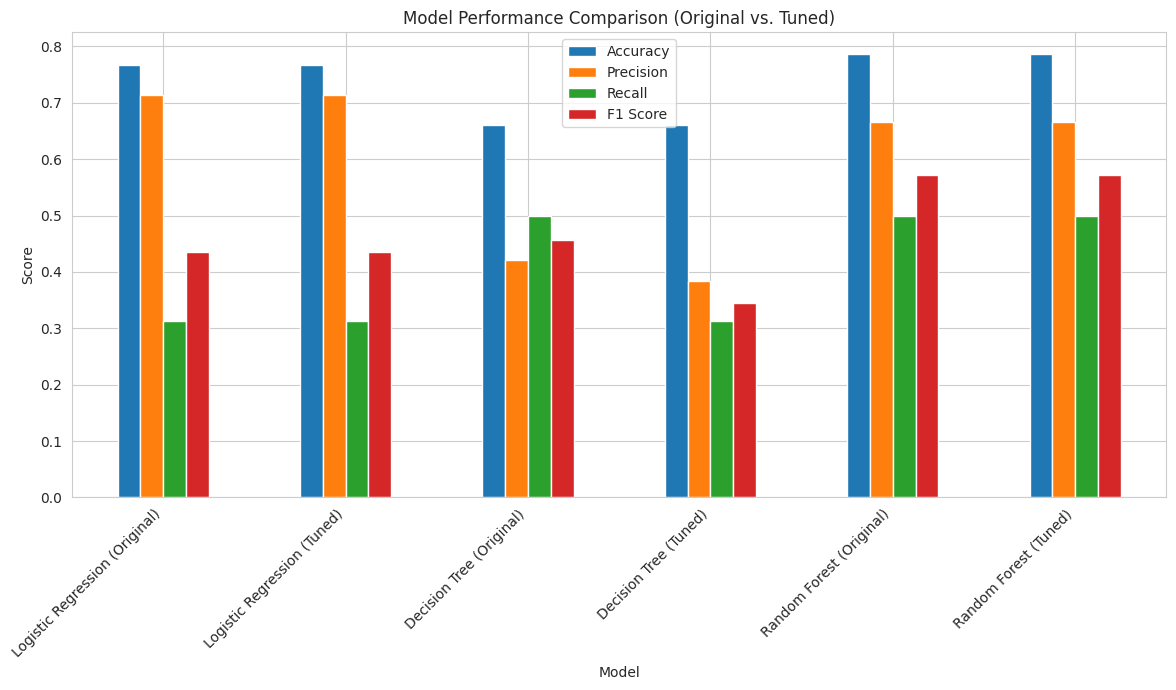

In [ ]:
# Compare models before and after tuning
comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression (Original)", "Logistic Regression (Tuned)",
        "Decision Tree (Original)", "Decision Tree (Tuned)",
        "Random Forest (Original)", "Random Forest (Tuned)"
    ],
    "Accuracy": [
        log_acc, log_acc_tuned,
        dt_acc, dt_acc_tuned,
        rf_acc, rf_acc_tuned
    ],
    "Precision": [
        log_prec, log_prec_tuned,
        dt_prec, dt_prec_tuned,
        rf_prec, rf_prec_tuned
    ],
    "Recall": [
        log_rec, log_rec_tuned,
        dt_rec, dt_rec_tuned,
        rf_rec, rf_rec_tuned
    ],
    "F1 Score": [
        log_f1, log_f1_tuned,
        dt_f1, dt_f1_tuned,
        rf_f1, rf_f1_tuned
    ]
})

print("Model Performance Comparison (Original vs. Tuned)")
print(comparison_results.set_index("Model"))

comparison_results.set_index("Model").plot(kind="bar", figsize=(12, 7))
plt.title("Model Performance Comparison (Original vs. Tuned)")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

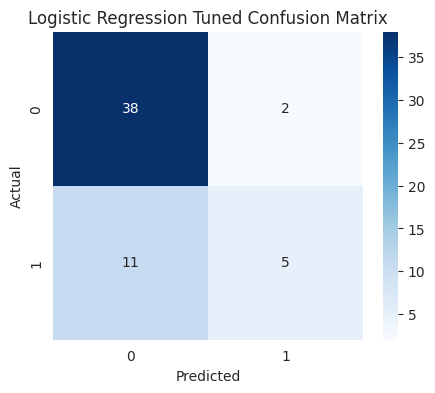

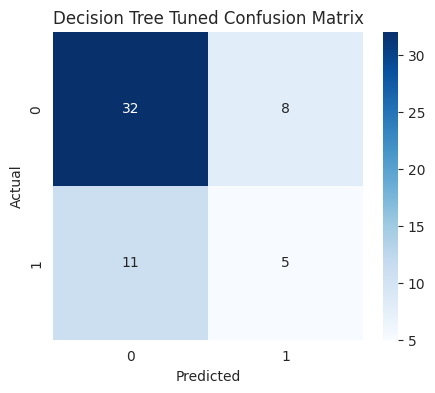

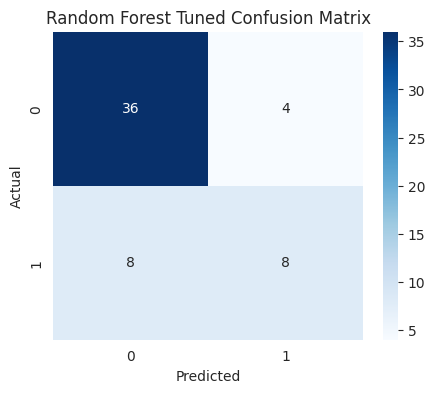

In [ ]:
cm_log_tuned = confusion_matrix(y_test, y_pred_log_tuned)
plt.figure(figsize=(5,4))
sns.heatmap(cm_log_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Feedback Working**



In [ ]:

# ADDRESSING CLASS IMBALANCE USING SMOTE


# SMOTE creates synthetic examples of the minority class.
# This is used because the dataset has fewer recurrence cases than non-recurrence cases.

try:
    from imblearn.over_sampling import SMOTE
except:
    !pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

print("Original training class distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nTraining class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Original training class distribution:
Class
0    156
1     65
Name: count, dtype: int64

Training class distribution after SMOTE:
Class
0    156
1    156
Name: count, dtype: int64


In [ ]:

# MODEL TRAINING AFTER SMOTE


# Logistic Regression after SMOTE
log_smote = LogisticRegression(max_iter=1000, random_state=42)
log_smote.fit(X_train_smote, y_train_smote)

y_pred_log_smote = log_smote.predict(X_test)

log_smote_acc = accuracy_score(y_test, y_pred_log_smote)
log_smote_prec = precision_score(y_test, y_pred_log_smote)
log_smote_rec = recall_score(y_test, y_pred_log_smote)
log_smote_f1 = f1_score(y_test, y_pred_log_smote)


# Decision Tree after SMOTE
dt_smote = DecisionTreeClassifier(random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)

y_pred_dt_smote = dt_smote.predict(X_test)

dt_smote_acc = accuracy_score(y_test, y_pred_dt_smote)
dt_smote_prec = precision_score(y_test, y_pred_dt_smote)
dt_smote_rec = recall_score(y_test, y_pred_dt_smote)
dt_smote_f1 = f1_score(y_test, y_pred_dt_smote)


# Random Forest after SMOTE
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)

rf_smote_acc = accuracy_score(y_test, y_pred_rf_smote)
rf_smote_prec = precision_score(y_test, y_pred_rf_smote)
rf_smote_rec = recall_score(y_test, y_pred_rf_smote)
rf_smote_f1 = f1_score(y_test, y_pred_rf_smote)


print("Logistic Regression with SMOTE")
print("Accuracy:", log_smote_acc)
print("Precision:", log_smote_prec)
print("Recall:", log_smote_rec)
print("F1 Score:", log_smote_f1)

print("\nDecision Tree with SMOTE")
print("Accuracy:", dt_smote_acc)
print("Precision:", dt_smote_prec)
print("Recall:", dt_smote_rec)
print("F1 Score:", dt_smote_f1)

print("\nRandom Forest with SMOTE")
print("Accuracy:", rf_smote_acc)
print("Precision:", rf_smote_prec)
print("Recall:", rf_smote_rec)
print("F1 Score:", rf_smote_f1)

Logistic Regression with SMOTE
Accuracy: 0.6428571428571429
Precision: 0.4090909090909091
Recall: 0.5625
F1 Score: 0.47368421052631576

Decision Tree with SMOTE
Accuracy: 0.6607142857142857
Precision: 0.4117647058823529
Recall: 0.4375
F1 Score: 0.42424242424242425

Random Forest with SMOTE
Accuracy: 0.7142857142857143
Precision: 0.5
Recall: 0.5
F1 Score: 0.5


In [ ]:

# COMPARISON TABLE: ORIGINAL, TUNED, AND SMOTE MODELS


final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression Original",
        "Logistic Regression Tuned",
        "Logistic Regression SMOTE",
        "Decision Tree Original",
        "Decision Tree Tuned",
        "Decision Tree SMOTE",
        "Random Forest Original",
        "Random Forest Tuned",
        "Random Forest SMOTE"
    ],
    "Accuracy": [
        log_acc, log_acc_tuned, log_smote_acc,
        dt_acc, dt_acc_tuned, dt_smote_acc,
        rf_acc, rf_acc_tuned, rf_smote_acc
    ],
    "Precision": [
        log_prec, log_prec_tuned, log_smote_prec,
        dt_prec, dt_prec_tuned, dt_smote_prec,
        rf_prec, rf_prec_tuned, rf_smote_prec
    ],
    "Recall": [
        log_rec, log_rec_tuned, log_smote_rec,
        dt_rec, dt_rec_tuned, dt_smote_rec,
        rf_rec, rf_rec_tuned, rf_smote_rec
    ],
    "F1 Score": [
        log_f1, log_f1_tuned, log_smote_f1,
        dt_f1, dt_f1_tuned, dt_smote_f1,
        rf_f1, rf_f1_tuned, rf_smote_f1
    ]
})

print("Final Model Comparison")
display(final_comparison)

Final Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression Original,0.767857,0.714286,0.3125,0.434783
1,Logistic Regression Tuned,0.767857,0.714286,0.3125,0.434783
2,Logistic Regression SMOTE,0.642857,0.409091,0.5625,0.473684
3,Decision Tree Original,0.660714,0.421053,0.5000,0.457143
4,Decision Tree Tuned,0.660714,0.384615,0.3125,0.344828
5,Decision Tree SMOTE,0.660714,0.411765,0.4375,0.424242
6,Random Forest Original,0.785714,0.666667,0.5000,0.571429
7,Random Forest Tuned,0.785714,0.666667,0.5000,0.571429
8,Random Forest SMOTE,0.714286,0.500000,0.5000,0.500000


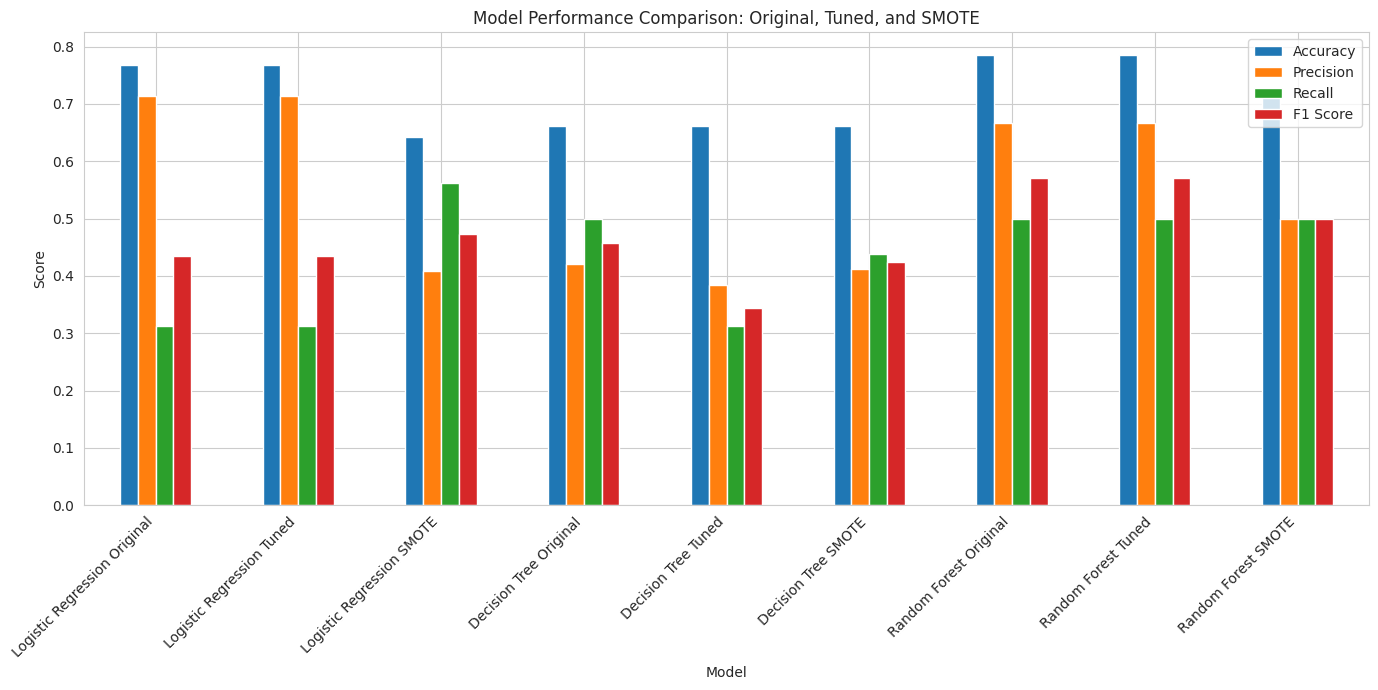

In [ ]:

# VISUAL COMPARISON OF MODEL PERFORMANCE


final_comparison.set_index("Model").plot(kind="bar", figsize=(14,7))

plt.title("Model Performance Comparison: Original, Tuned, and SMOTE")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

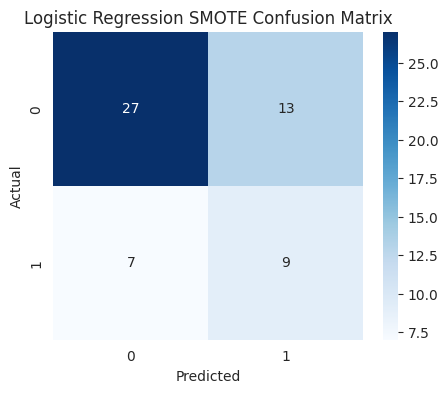

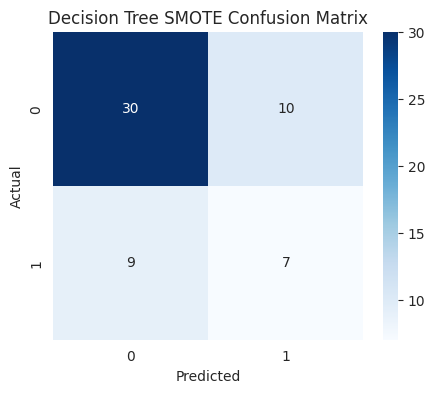

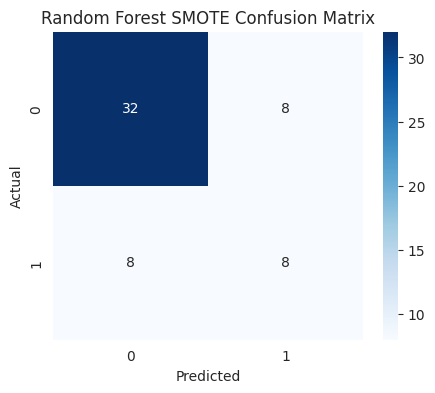

In [ ]:

# CONFUSION MATRICES AFTER SMOTE


models_smote = {
    "Logistic Regression SMOTE": y_pred_log_smote,
    "Decision Tree SMOTE": y_pred_dt_smote,
    "Random Forest SMOTE": y_pred_rf_smote
}

for model_name, predictions in models_smote.items():
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(model_name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

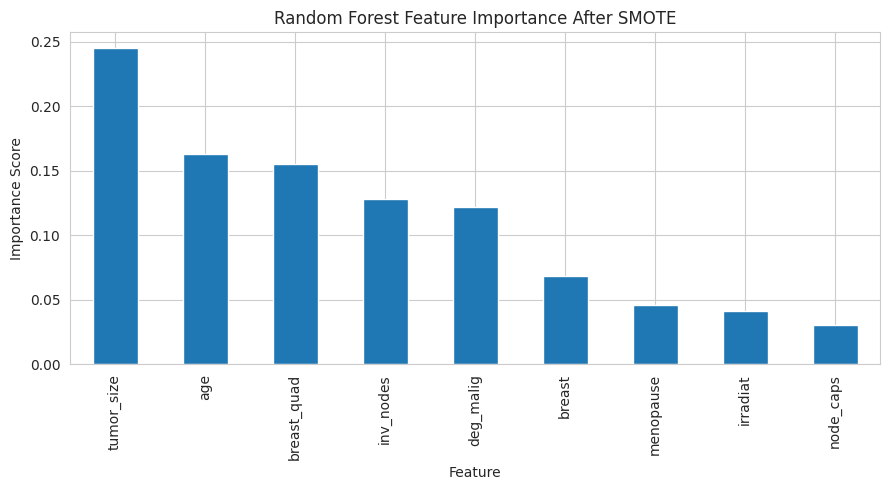

Feature Importance Scores:
tumor_size     0.244997
age            0.162737
breast_quad    0.155012
inv_nodes      0.127959
deg_malig      0.122316
breast         0.068829
menopause      0.046299
irradiat       0.041460
node_caps      0.030389
dtype: float64


In [ ]:

# FEATURE IMPORTANCE AFTER SMOTE - RANDOM FOREST


# Random Forest is used here because it provides feature importance values.
# This helps explain which clinical variables contributed most to prediction.

rf_smote_importance = pd.Series(
    rf_smote.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(9,5))
rf_smote_importance.plot(kind="bar")
plt.title("Random Forest Feature Importance After SMOTE")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

print("Feature Importance Scores:")
print(rf_smote_importance)

In [ ]:

# ONE-HOT ENCODING ANALYSIS
# Purpose: Check relationships without artificial ordinal values


# Create a fresh copy of the cleaned dataset
df_ohe = df.copy()

# Identify target and feature columns
target_col = 'Class'

# One-Hot Encode categorical variables
df_ohe_encoded = pd.get_dummies(
    df_ohe,
    columns=[col for col in df_ohe.columns if col != target_col],
    drop_first=False
)

# Convert target to numeric if it is still categorical/text
if df_ohe_encoded[target_col].dtype == 'object':
    df_ohe_encoded[target_col] = df_ohe_encoded[target_col].map({
        'no-recurrence-events': 0,
        'recurrence-events': 1
    })

print("One-Hot Encoded Dataset Shape:")
print(df_ohe_encoded.shape)

df_ohe_encoded.head()

One-Hot Encoded Dataset Shape:
(277, 42)


,Class,age_0,age_1,age_2,age_3,age_4,age_5,menopause_0,menopause_1,menopause_2,...,deg_malig_2,breast_0,breast_1,breast_quad_0,breast_quad_1,breast_quad_2,breast_quad_3,breast_quad_4,irradiat_0,irradiat_1
0,0,False,True,False,False,False,False,False,False,True,...,True,True,False,False,True,False,False,False,True,False
1,0,False,False,True,False,False,False,False,False,True,...,False,False,True,False,False,False,False,True,True,False
2,0,False,False,True,False,False,False,False,False,True,...,False,True,False,False,True,False,False,False,True,False
3,0,False,False,False,False,True,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
4,0,False,False,True,False,False,False,False,False,True,...,False,False,True,False,False,False,True,False,True,False


In [ ]:

# CORRELATION OF ONE-HOT ENCODED VARIABLES WITH TARGET


# Calculate correlations with target Class
target_correlations_ohe = df_ohe_encoded.corr()[target_col].sort_values(ascending=False)

print("Top Positive Correlations with Recurrence:")
print(target_correlations_ohe.head(15))

print("\nTop Negative Correlations with Recurrence:")
print(target_correlations_ohe.tail(15))

Top Positive Correlations with Recurrence:
Class            1.000000
deg_malig_2      0.348085
node_caps_1      0.289002
irradiat_1       0.226020
inv_nodes_4      0.170700
inv_nodes_5      0.166291
inv_nodes_6      0.149332
tumor_size_5     0.143943
age_1            0.105570
inv_nodes_3      0.093633
inv_nodes_1      0.086090
breast_quad_4    0.082078
menopause_2      0.070514
inv_nodes_2      0.067903
tumor_size_4     0.063206
Name: Class, dtype: float64

Top Negative Correlations with Recurrence:
breast_quad_2   -0.041693
menopause_0     -0.047401
tumor_size_0    -0.063472
breast_quad_0   -0.064188
tumor_size_2    -0.064293
tumor_size_9    -0.077815
age_3           -0.077901
age_5           -0.087160
menopause_1     -0.087160
deg_malig_1     -0.154682
tumor_size_1    -0.189244
deg_malig_0     -0.191875
irradiat_0      -0.226020
node_caps_0     -0.289002
inv_nodes_0     -0.334066
Name: Class, dtype: float64


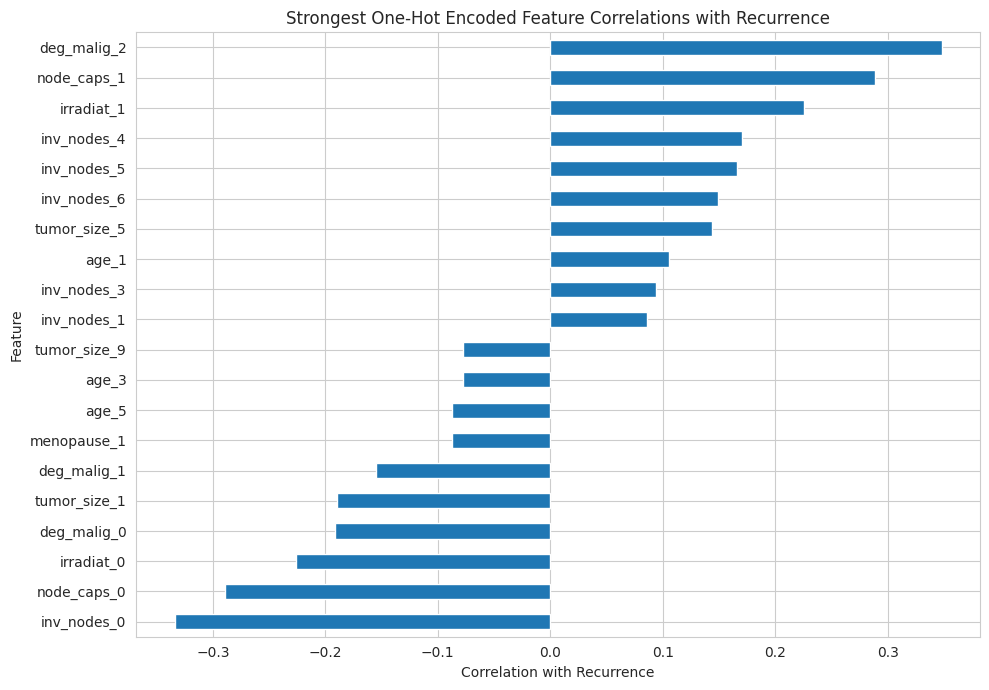

In [ ]:

# VISUALISE TOP RELATIONSHIPS WITH RECURRENCE


# Remove target itself from correlation list
target_corr_plot = target_correlations_ohe.drop(target_col)

# Select strongest positive and negative relationships
top_corr_features = pd.concat([
    target_corr_plot.head(10),
    target_corr_plot.tail(10)
])

plt.figure(figsize=(10, 7))
top_corr_features.sort_values().plot(kind='barh')

plt.title("Strongest One-Hot Encoded Feature Correlations with Recurrence")
plt.xlabel("Correlation with Recurrence")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

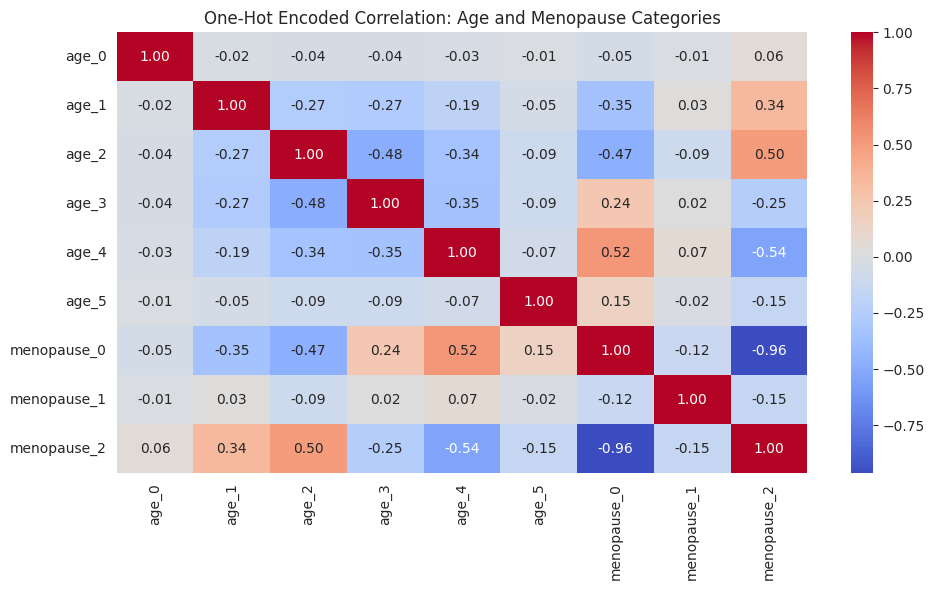

In [ ]:

# ONE-HOT ENCODING: AGE AND MENOPAUSE RELATIONSHIP CHECK


# Show only age and menopause dummy variables
age_menopause_cols = [
    col for col in df_ohe_encoded.columns
    if col.startswith('age_') or col.startswith('menopause_')
]

age_menopause_corr = df_ohe_encoded[age_menopause_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(age_menopause_corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("One-Hot Encoded Correlation: Age and Menopause Categories")
plt.tight_layout()
plt.show()

In [ ]:

# ONE-HOT ENCODING MODEL COMPARISON


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Separate features and target
X_ohe = df_ohe_encoded.drop(target_col, axis=1)
y_ohe = df_ohe_encoded[target_col]

# Train-test split
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(
    X_ohe,
    y_ohe,
    test_size=0.2,
    random_state=42,
    stratify=y_ohe
)

# Train models using One-Hot Encoded data
log_ohe = LogisticRegression(max_iter=1000, random_state=42)
dt_ohe = DecisionTreeClassifier(random_state=42)
rf_ohe = RandomForestClassifier(random_state=42)

models_ohe = {
    "Logistic Regression OHE": log_ohe,
    "Decision Tree OHE": dt_ohe,
    "Random Forest OHE": rf_ohe
}

ohe_results = []

for model_name, model in models_ohe.items():
    model.fit(X_train_ohe, y_train_ohe)
    y_pred_ohe = model.predict(X_test_ohe)

    ohe_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_ohe, y_pred_ohe),
        "Precision": precision_score(y_test_ohe, y_pred_ohe),
        "Recall": recall_score(y_test_ohe, y_pred_ohe),
        "F1 Score": f1_score(y_test_ohe, y_pred_ohe)
    })

ohe_results_df = pd.DataFrame(ohe_results)

print("One-Hot Encoding Model Results")
display(ohe_results_df)

One-Hot Encoding Model Results


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression OHE,0.696429,0.454545,0.3125,0.370370
1,Decision Tree OHE,0.660714,0.411765,0.4375,0.424242
2,Random Forest OHE,0.767857,0.636364,0.4375,0.518519


In [ ]:

# ONE-HOT ENCODING FOR QUADRANT VARIABLE
# Purpose: Avoid artificial ordinal relationship for anatomical location


df_quadrant_ohe = df.copy()

df_quadrant_ohe = pd.get_dummies(
    df_quadrant_ohe,
    columns=['breast_quad'],
    drop_first=False
)

print("Dataset shape after applying One-Hot Encoding to quadrant variable:")
print(df_quadrant_ohe.shape)

df_quadrant_ohe.head()

Dataset shape after applying One-Hot Encoding to quadrant variable:
(277, 14)


,Class,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig,breast,irradiat,breast_quad_0,breast_quad_1,breast_quad_2,breast_quad_3,breast_quad_4
0,0,1,2,5,0,0,2,0,0,False,True,False,False,False
1,0,2,2,3,0,0,1,1,0,False,False,False,False,True
2,0,2,2,3,0,0,1,0,0,False,True,False,False,False
3,0,4,0,2,0,0,1,1,0,False,False,True,False,False
4,0,2,2,0,0,0,1,1,0,False,False,False,True,False


In [ ]:

# FEATURE AND TARGET SEPARATION


X_quadrant_ohe = df_quadrant_ohe.drop('Class', axis=1)
y_quadrant_ohe = df_quadrant_ohe['Class']

X_train_quadrant_ohe, X_test_quadrant_ohe, y_train_quadrant_ohe, y_test_quadrant_ohe = train_test_split(
    X_quadrant_ohe,
    y_quadrant_ohe,
    test_size=0.2,
    random_state=42,
    stratify=y_quadrant_ohe
)

In [ ]:

# TRAIN MODELS WITH QUADRANT ONE-HOT ENCODING


models_quadrant_ohe = {
    "Logistic Regression with Quadrant OHE": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree with Quadrant OHE": DecisionTreeClassifier(random_state=42),
    "Random Forest with Quadrant OHE": RandomForestClassifier(random_state=42)
}

quadrant_ohe_results = []

for model_name, model in models_quadrant_ohe.items():
    model.fit(X_train_quadrant_ohe, y_train_quadrant_ohe)
    y_pred_quadrant_ohe = model.predict(X_test_quadrant_ohe)

    quadrant_ohe_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_quadrant_ohe, y_pred_quadrant_ohe),
        "Precision": precision_score(y_test_quadrant_ohe, y_pred_quadrant_ohe),
        "Recall": recall_score(y_test_quadrant_ohe, y_pred_quadrant_ohe),
        "F1 Score": f1_score(y_test_quadrant_ohe, y_pred_quadrant_ohe)
    })

quadrant_ohe_results_df = pd.DataFrame(quadrant_ohe_results)

print("Model Results After Applying One-Hot Encoding to Quadrant Variable")
display(quadrant_ohe_results_df)

Model Results After Applying One-Hot Encoding to Quadrant Variable


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression with Quadrant OHE,0.750000,0.600000,0.3750,0.461538
1,Decision Tree with Quadrant OHE,0.625000,0.352941,0.3750,0.363636
2,Random Forest with Quadrant OHE,0.785714,0.700000,0.4375,0.538462


In [ ]:

# QUADRANT ONE-HOT ENCODING WITH SMOTE


try:
    from imblearn.over_sampling import SMOTE
except:
    !pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

smote_quadrant_ohe = SMOTE(random_state=42)

X_train_quadrant_ohe_smote, y_train_quadrant_ohe_smote = smote_quadrant_ohe.fit_resample(
    X_train_quadrant_ohe,
    y_train_quadrant_ohe
)

quadrant_ohe_smote_results = []

models_quadrant_ohe_smote = {
    "Logistic Regression with Quadrant OHE + SMOTE": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree with Quadrant OHE + SMOTE": DecisionTreeClassifier(random_state=42),
    "Random Forest with Quadrant OHE + SMOTE": RandomForestClassifier(random_state=42)
}

for model_name, model in models_quadrant_ohe_smote.items():
    model.fit(X_train_quadrant_ohe_smote, y_train_quadrant_ohe_smote)
    y_pred_quadrant_ohe_smote = model.predict(X_test_quadrant_ohe)

    quadrant_ohe_smote_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_quadrant_ohe, y_pred_quadrant_ohe_smote),
        "Precision": precision_score(y_test_quadrant_ohe, y_pred_quadrant_ohe_smote),
        "Recall": recall_score(y_test_quadrant_ohe, y_pred_quadrant_ohe_smote),
        "F1 Score": f1_score(y_test_quadrant_ohe, y_pred_quadrant_ohe_smote)
    })

quadrant_ohe_smote_results_df = pd.DataFrame(quadrant_ohe_smote_results)

print("Model Results After Applying One-Hot Encoding to Quadrant Variable with SMOTE")
display(quadrant_ohe_smote_results_df)

Model Results After Applying One-Hot Encoding to Quadrant Variable with SMOTE


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression with Quadrant OHE + SMOTE,0.660714,0.428571,0.5625,0.486486
1,Decision Tree with Quadrant OHE + SMOTE,0.696429,0.470588,0.5000,0.484848
2,Random Forest with Quadrant OHE + SMOTE,0.714286,0.500000,0.5625,0.529412


In [ ]:
# ============================================================
# FINAL COMPARISON: ALL ENCODING APPROACHES
# ============================================================

all_encoding_comparison = pd.concat([
    final_comparison.assign(Encoding="Label Encoding"),
    quadrant_ohe_results_df.assign(Encoding="Quadrant OHE"),
    quadrant_ohe_smote_results_df.assign(Encoding="Quadrant OHE + SMOTE"),
    ohe_results_df.assign(Encoding="Full One-Hot Encoding")
], ignore_index=True)

print("Final Comparison of All Encoding Strategies")
display(all_encoding_comparison)

Final Comparison of All Encoding Strategies


,Model,Accuracy,Precision,Recall,F1 Score,Encoding
0,Logistic Regression Original,0.767857,0.714286,0.3125,0.434783,Label Encoding
1,Logistic Regression Tuned,0.767857,0.714286,0.3125,0.434783,Label Encoding
2,Logistic Regression SMOTE,0.642857,0.409091,0.5625,0.473684,Label Encoding
3,Decision Tree Original,0.660714,0.421053,0.5000,0.457143,Label Encoding
4,Decision Tree Tuned,0.660714,0.384615,0.3125,0.344828,Label Encoding
5,Decision Tree SMOTE,0.660714,0.411765,0.4375,0.424242,Label Encoding
6,Random Forest Original,0.785714,0.666667,0.5000,0.571429,Label Encoding
7,Random Forest Tuned,0.785714,0.666667,0.5000,0.571429,Label Encoding
8,Random Forest SMOTE,0.714286,0.500000,0.5000,0.500000,Label Encoding
9,Logistic Regression with Quadrant OHE,0.750000,0.600000,0.3750,0.461538,Quadrant OHE
